In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

# Завантаження даних (переконайся, що файли знаходяться у тій же папці, або вкажи правильний шлях)
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

# Об'єднання таблиць за полем movieId
df = pd.merge(ratings, movies, on='movieId')

# Фільтрація: залишаємо лише оцінки >= 4.0
df_liked = df[df['rating'] >= 4.0]

# Виведення розмірів таблиць та унікальних значень
print(f"Розмір вихідної таблиці з високими оцінками: {df_liked.shape}")
print(f"Кількість унікальних користувачів: {df_liked['userId'].nunique()}")
print(f"Кількість унікальних фільмів: {df_liked['movieId'].nunique()}")

Розмір вихідної таблиці з високими оцінками: (48580, 6)
Кількість унікальних користувачів: 609
Кількість унікальних фільмів: 6298


In [99]:
# Створення зведеної таблиці (транзакційного формату)
basket = df_liked.pivot_table(index='userId', columns='title', values='rating', aggfunc='any', fill_value=False)

# Конвертація булевих значень (якщо необхідно для mlxtend)
basket = basket.astype(bool)

# Виведення кількох перших рядків для перевірки
display(basket.head())


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [100]:
# Робимо копію нашої топ-10 таблиці
clean_top_10 = top_10_itemsets.copy()

# Перетворюємо frozenset на звичайний рядок, об'єднуючи назви через кому
clean_top_10['itemsets'] = clean_top_10['itemsets'].apply(lambda x: ', '.join(list(x)))

# Скидаємо старі номери
clean_top_10 = clean_top_10.reset_index(drop=True)

# Хитрий трюк: замінюємо індекси на порожні рядки, щоб їх не було видно
clean_top_10.index = [''] * len(clean_top_10)

print("\nТоп-10 найпопулярніших фільмів:")
display(clean_top_10)


Топ-10 найпопулярніших фільмів:


,support,itemsets
,0.449918,"Shawshank Redemption, The (1994)"
,0.408867,Forrest Gump (1994)
,0.400657,Pulp Fiction (1994)
,0.369458,"Silence of the Lambs, The (1991)"
,0.364532,"Matrix, The (1999)"
,0.330049,Star Wars: Episode IV - A New Hope (1977)
,0.293924,Fight Club (1999)
,0.287356,Schindler's List (1993)
,0.275862,"Forrest Gump (1994), Shawshank Redemption, The..."
,0.275862,Star Wars: Episode V - The Empire Strikes Back...



Топ-10 асоціативних правил за Lift:


,antecedents,consequents,support,confidence,lift
37203,"Lord of the Rings: The Return of the King, The...",Star Wars: Episode VI - Return of the Jedi (19...,0.07225,0.785714,8.394737
37242,Star Wars: Episode VI - Return of the Jedi (19...,"Lord of the Rings: The Return of the King, The...",0.07225,0.771930,8.394737
37210,"Star Wars: Episode IV - A New Hope (1977), Lor...","Lord of the Rings: The Return of the King, The...",0.07225,0.880000,8.373750
37235,"Lord of the Rings: The Return of the King, The...","Star Wars: Episode IV - A New Hope (1977), Lor...",0.07225,0.687500,8.373750
37224,"Star Wars: Episode IV - A New Hope (1977), Lor...","Lord of the Rings: The Return of the King, The...",0.07225,0.698413,8.179487
37221,"Lord of the Rings: The Return of the King, The...","Star Wars: Episode IV - A New Hope (1977), Lor...",0.07225,0.846154,8.179487
37229,Star Wars: Episode VI - Return of the Jedi (19...,"Lord of the Rings: The Return of the King, The...",0.07225,0.800000,8.120000
37216,"Lord of the Rings: The Return of the King, The...",Star Wars: Episode VI - Return of the Jedi (19...,0.07225,0.733333,8.120000
37202,"Lord of the Rings: The Return of the King, The...","Lord of the Rings: The Two Towers, The (2002),...",0.07225,0.897959,8.042017
37243,"Lord of the Rings: The Two Towers, The (2002),...","Lord of the Rings: The Return of the King, The...",0.07225,0.647059,8.042017


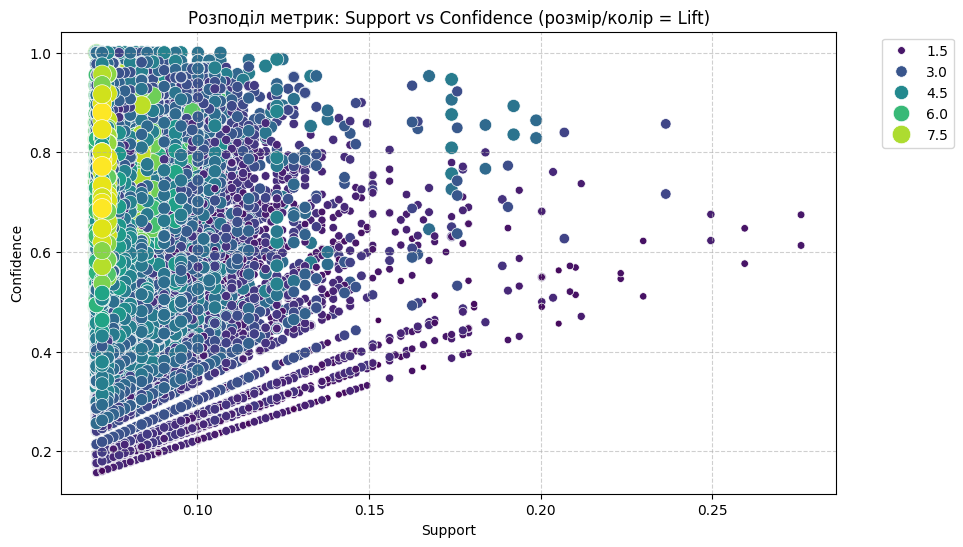

In [101]:
# Побудова асоціативних правил
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Сортування та виведення топ-10 правил за метрикою lift
top_10_rules = rules.sort_values(by='lift', ascending=False).head(10).copy()
print("\nТоп-10 асоціативних правил за Lift:")
top_10_rules['antecedents'] = top_10_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
top_10_rules['consequents'] = top_10_rules['consequents'].apply(lambda x: ', '.join(list(x)))
display(top_10_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# Візуалізація розподілу метрик: Support vs Confidence
plt.figure(figsize=(10, 6))
sns.scatterplot(x='support', y='confidence', size='lift', hue='lift', data=rules, palette='viridis', sizes=(20, 200))
plt.title('Розподіл метрик: Support vs Confidence (розмір/колір = Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Аналіз та висновки

a. Зробити висновки щодо того, як асоціативні правила можна застосувати у системах рекомендацій

    - На основі цих правил можна підбирати товари, фільми, музику чи навіть навчальні курси, які підійдуть саме конкретному споживачу в цей момент. Це збільшує попит та продажі для компанії, яка користується цими правилами, оскільки користувач бачитиме тільки те, що йому цікаво або потрібно


b. Оцінити вплив параметрів min_support і min_confidence на кількість і якість знайдених правил.

    - Щодо min_support, то на візуалізації видно, що основна маса правил (зокрема найцінніші жовті точки з високим Lift) скупчена зліва. Це означає, що висока підтримка просто знищить кількість результатів, залишивши лише загальновідомі масові товари та прибравши унікальні рекомендації. Тобто низька підтримка дає більше цікавих правил, але ризикує додати шуму.

    - Вплив min_confidence видно по вертикалі: чим вищий цей поріг, тим менше правил залишається, але їхня якість і точність зростають. Висока достовірність гарантує, що система не буде спамити випадковими порадами, а пропонуватиме лише те, що справді купують разом.